# Action Recognition
 Foundations of Machine Learning SS26    
 Group 11 - G. Sammet, M. Schlichting
### Overall Goal
- Classify 4 actions
### Dataset 
- RGB videos
    - ca 2 seconds long
    - resolution 1920x1080
- ca. 900 videos per action
- 4 actions: waving, capitulate, cross arms and clapping

    **Aquisition:**    
    We contacted ROSE Lab to get permission for the download. Due to hardware limits we downloaded the zip files in batched and ran the ``process_NTU.py`` to extract only the action classes we wanted.

    *The research in this project used the NTU RGB+D (or NTU RGB+D 120) Action Recognition Dataset made available by the ROSE Lab at the Nanyang Technological University, Singapore.*

    ROSE Lab. Action recognition datasets: “NTU RGB+D” dataset and “NTU RGB+D 120” dataset [Dataset]. https://rose1.ntu.edu.sg/dataset/actionRecognition/  

### Imports

In [122]:
from pathlib import Path
import torch
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

import random
from PIL import Image
import matplotlib.pyplot as plt

## Experiment 1: Simple One-Frame-Model
single frame -> pre-trained ResNet18 -> custom classifier output layer

### Load ResNet18 Model & Dataset

In [5]:
# load pretrained model
weights = ResNet18_Weights.DEFAULT
resnet_model = resnet18(weights=weights)

# modify last layer to 4 classes
resnet_model.fc = torch.nn.Linear(resnet_model.fc.in_features, 4)

# define loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(resnet_model.fc.parameters(), lr=0.001, momentum=0.9)

# define transformations for our dataset
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [17]:
# load data and transform
output_dir = Path("data/three_quarter_frame")  
train_dataset = ImageFolder((str(output_dir / "train")), transform=transform)
val_dataset = ImageFolder((str(output_dir / "val")), transform=transform)
test_dataset = ImageFolder((str(output_dir/ "test")), transform=transform)

train_loader_three_quarter = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_three_quarter = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader_three_quarter = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Training Loop

In [ ]:
# training loop 
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    # determine device
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

    for epoch in range(num_epochs):
        # training mode
        model.train()

        running_loss = 0.0
        running_corrects = 0

        # iterate training data loader
        for inputs, labels in train_loader:
            # put to device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # reset gradients 
            optimizer.zero_grad()

            # forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # epoch training loss and accuracy 
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects.float() / len(train_loader.dataset)


        ## Evaluation
        model.eval()
        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # forward pass
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        # validation loss and accuracy 
        val_loss = running_loss / len(val_loader.dataset)
        val_acc = running_corrects.float() / len(val_loader.dataset)

        print(f'Epoch [{epoch+1}/{num_epochs}], train loss: {train_loss:.4f}, train acc: {train_acc:.4f}, val loss: {val_loss:.4f}, val acc: {val_acc:.4f} \n')

In [ ]:
# train model
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model_three_quarter = resnet_model.to(device)

train(model_three_quarter, train_loader_three_quarter, val_loader_three_quarter, criterion, optimizer, num_epochs=10)

# save checkpoint of model
checkpoint = {
    "model_three_quarter_state_dict": model_three_quarter.state_dict(),
    "optimizer_model_three_quarter_state_dict": optimizer.state_dict(),
    "epoch": 10,
}

torch.save(
    checkpoint,
    "checkpoints/model_three_quarter_checkpoint.pth"
)

Epoch [1/10], train loss: 1.1948, train acc: 0.4292, val loss: 0.9846, val acc: 0.5491    
Epoch [2/10], train loss: 0.9416, train acc: 0.5825, val loss: 0.8774, val acc: 0.5947    
Epoch [3/10], train loss: 0.8520, train acc: 0.6257, val loss: 0.8262, val acc: 0.6316    
Epoch [4/10], train loss: 0.8003, train acc: 0.6652, val loss: 0.7976, val acc: 0.6474    
Epoch [5/10], train loss: 0.7734, train acc: 0.6678, val loss: 0.7642, val acc: 0.6579    
Epoch [6/10], train loss: 0.7405, train acc: 0.6885, val loss: 0.7513, val acc: 0.6544    
Epoch [7/10], train loss: 0.7162, train acc: 0.6933, val loss: 0.7364, val acc: 0.6667    
Epoch [8/10], train loss: 0.6940, train acc: 0.7073, val loss: 0.7236, val acc: 0.6614    
Epoch [9/10], train loss: 0.6970, train acc: 0.7035, val loss: 0.7247, val acc: 0.6807    
Epoch [10/10], train loss: 0.6785, train acc: 0.7166, val loss: 0.7169, val acc: 0.6789    

### Evaluation Function

In [ ]:
def evaluate_model(model, test_loader, device):
    # evaluation mode
    model.eval()

    # Initialize dictionaries to store correct and total predictions
    correct_pred = {classname: 0 for classname in test_loader.dataset.classes}
    total_pred = {classname: 0 for classname in test_loader.dataset.classes}

    # track labels and predictions
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in test_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            # forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            # collect preds and labels
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            # update correct and total preds
            for label, prediction in zip(labels, preds):
                classname = test_loader.dataset.classes[label]
                if label == prediction:
                    correct_pred[classname] += 1
                total_pred[classname] += 1

    # accuracy per class
    accuracy_per_class = {classname: correct_pred[classname] / total_pred[classname] if total_pred[classname] > 0 else 0
                          for classname in test_loader.dataset.classes}

    # overall accuracy
    overall_accuracy = accuracy_score(all_labels, all_preds)

    print("Accuracy per class:")
    for classname, accuracy in accuracy_per_class.items():
        print(f"{classname}: {accuracy:.4f}")
    print(f"Overall Accuracy: {overall_accuracy:.4f}")

    return accuracy_per_class, overall_accuracy

In [ ]:
# load model
checkpoint = torch.load("checkpoints/model_three_quarter_checkpoint.pth",map_location=device)

model_three_quarter.load_state_dict(checkpoint["model_three_quarter_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_model_three_quarter_state_dict"])
model_three_quarter.to(device)

#evaluate
acc_classes_three_quarter, acc_total__three_quarter = evaluate_model(model_three_quarter, test_loader_three_quarter, device)

Accuracy per class:
class1: 0.9861
class2: 0.3566
class3: 0.7692
class4: 0.5455

Overall Accuracy: 0.6649


## Experiment 2: 3-Model-3-Frames-Approach
3 frames per video -> one model per frame type -> average over class predictions -> classification

#### Middle-Frame-Model

In [63]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.SGD(resnet_model.fc.parameters(), lr=0.001, momentum=0.9)

# load datat for middle frame
output_dir = Path("data/middle_frame")  
train_dataset = ImageFolder((str(output_dir / "train")), transform=transform)
val_dataset = ImageFolder((str(output_dir / "val")), transform=transform)
test_dataset = ImageFolder((str(output_dir/ "test")), transform=transform)

train_loader_middle = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_middle = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader_middle = DataLoader(test_dataset, batch_size=32, shuffle=False)

# train model 2
model_middle = resnet_model.to(device)
train(model_middle, train_loader_middle, val_loader_middle, criterion, optimizer, num_epochs=10)

# save checkpoint of model
checkpoint = {
    "model_middle_state_dict": model_middle.state_dict(),
    "optimizer_middle_state_dict": optimizer.state_dict(),
    "epoch": 10,
}

torch.save(
    checkpoint,
    "checkpoints/model_middle_checkpoint.pth"
)

Epoch [1/10], train loss: 0.6268, train acc: 0.7257, val loss: 0.7456, val acc: 0.6211
Epoch [2/10], train loss: 0.6447, train acc: 0.7178, val loss: 0.7463, val acc: 0.6404
Epoch [3/10], train loss: 0.6357, train acc: 0.7227, val loss: 0.7553, val acc: 0.6474
Epoch [4/10], train loss: 0.6205, train acc: 0.7287, val loss: 0.7501, val acc: 0.6158
Epoch [5/10], train loss: 0.6207, train acc: 0.7260, val loss: 0.7528, val acc: 0.6456
Epoch [6/10], train loss: 0.6342, train acc: 0.7193, val loss: 0.7509, val acc: 0.6316
Epoch [7/10], train loss: 0.6191, train acc: 0.7279, val loss: 0.7380, val acc: 0.6281
Epoch [8/10], train loss: 0.6327, train acc: 0.7275, val loss: 0.7525, val acc: 0.6632
Epoch [9/10], train loss: 0.6128, train acc: 0.7347, val loss: 0.7353, val acc: 0.6526
Epoch [10/10], train loss: 0.6177, train acc: 0.7245, val loss: 0.7566, val acc: 0.6404


In [64]:
# load model
checkpoint = torch.load("checkpoints/model_middle_checkpoint.pth",map_location=device)

model_middle.load_state_dict(checkpoint["model_middle_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_middle_state_dict"])
model_middle.to(device)

#evaluate
evaluate_model(model_middle, test_loader_middle, device)

Accuracy per class:
class1: 0.9861
class2: 0.6154
class3: 0.7203
class4: 0.3846

Overall Accuracy: 0.6771


#### End-Frame-Model

In [103]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.SGD(resnet_model.fc.parameters(), lr=0.001, momentum=0.9) 

# load datat for end frame
output_dir = Path("data/end_frame")  
train_dataset = ImageFolder((str(output_dir / "train")), transform=transform)
val_dataset = ImageFolder((str(output_dir / "val")), transform=transform)
test_dataset = ImageFolder((str(output_dir / "test")), transform=transform)

train_loader_end = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_end = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader_end = DataLoader(test_dataset, batch_size=32, shuffle=False)

# train model 2
model_end = resnet_model.to(device)
train(model_end, train_loader_end, val_loader_end, criterion, optimizer, num_epochs=10)

# save checkpoint of model
checkpoint = {
    "model_end_state_dict": model_end.state_dict(),
    "optimizer_end_state_dict": optimizer.state_dict(),
    "epoch": 10,
}

torch.save(
    checkpoint,
    "checkpoints/model_end_checkpoint.pth"
)

Epoch [1/10], train loss: 0.6355, train acc: 0.7212, val loss: 0.6991, val acc: 0.6667


KeyboardInterrupt: 

In [ ]:
# load model
checkpoint = torch.load("checkpoints/model_end_checkpoint.pth",map_location=device)

model_end.load_state_dict(checkpoint["model_end_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_end_state_dict"])
model_end.to(device)

#evaluate
evaluate_model(model_end, test_loader_end, device)

### Combine Models

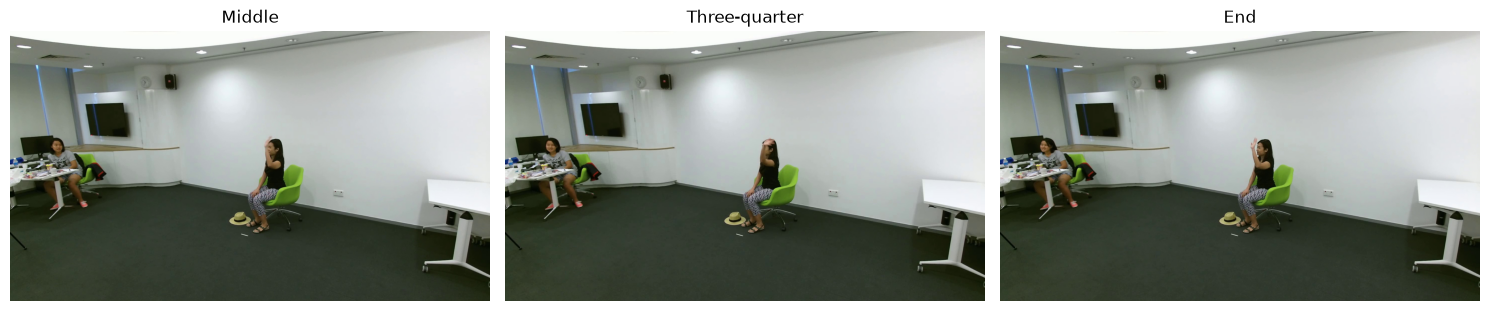

Middle Model Confidence: 77.45%
Middle Model Probs: tensor([[1.3453e-04, 7.7451e-01, 8.0096e-02, 1.4526e-01]])
Middle Model Prediction: Clapping = Class 2
---
Three-quarter Model Confidence: 57.99%
Three-quarter Model Probs: tensor([[0.0075, 0.3341, 0.0785, 0.5799]])
Three-quarter Model Prediction: Hand Waving = Class 4
---


FileNotFoundError: [Errno 2] No such file or directory: 'checkpoints/model_end_checkpoint.pth'

In [124]:

#random.seed(1)
def three_model_classifier(device, video_name="random", display_on = True):

    class_names = ["Capitulate  = Class 1", "Clapping = Class 2", "Cross Arms = Class 3", "Hand Waving = Class 4"]
    # use same transform configuration
    transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
    
    overall_probs = torch.Tensor([0,0,0,0])

    if video_name == "random":
        # choose random frame from test file
        random_frame = random.choice(list(Path("data/three_quarter_frame/test").glob("class*/*.jpg")))
        # get video name
        video_name = random_frame.name.partition("rgb")[0] + "rgb"

    # find frames 
    middle_path = next(Path("data/middle_frame/").rglob(f"{video_name}_ending.jpg"), None)
    three_quarter_path = next(Path("data/three_quarter_frame/").rglob(f"{video_name}_ending.jpg"), None)
    end_path = next(Path("data/end_frame/").rglob(f"{video_name}_ending.jpg"), None)

    paths = [
                ("Middle", middle_path),
                ("Three-quarter", three_quarter_path),
                ("End", end_path)
            ]
    
    # find true label
    true_label = three_quarter_path.parent.name

    # display frames
    if display_on:
        _, axes = plt.subplots(1, 3,figsize=(15, 5))
        
        for ax, (title, path) in zip(axes, paths):
            image = Image.open(path).convert("RGB")
            ax.imshow(image)
            ax.set_title(title)
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    # get predictions
    for (title,path), model_path in zip(paths, ["model_middle_", "model_three_quarter_", "model_end_"]):
        # transform image
        image = Image.open(path).convert("RGB")
        frame = transform(image).unsqueeze(0).to(device)

        # get model
        model = resnet_model.to(device)
        checkpoint = torch.load(f"checkpoints/{model_path}checkpoint.pth",map_location=device)
        model.load_state_dict(checkpoint[f"{model_path}state_dict"])
        model = model.to(device)
        model.eval()

        with torch.no_grad():
            output = model(frame)
            probabilities = torch.softmax(output, dim=1)
            confidence = probabilities[0, torch.argmax(probabilities, dim=1).item()].item()
            overall_probs = torch.add(overall_probs, probabilities)

        if display_on:
            print(f"{title} Model Confidence: {confidence:.2%}")
            print(f"{title} Model Probs: {probabilities}")
            print(f"{title} Model Prediction: {class_names[torch.argmax(probabilities, dim=1).item()]}")
            print("---")
    if display_on:
        print("Overall Probabilities: ", overall_probs)
        print("Overall Prediction: ", class_names[torch.argmax(overall_probs, dim=1).item()])
        print("True Label:", true_label)
    return torch.argmax(overall_probs, dim=1).item()

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
pred = three_model_classifier(device, video_name="random", display_on=True)